<a href="https://colab.research.google.com/github/Mizuko821/master_thesis/blob/main/%E5%AE%9F%E9%A8%931_%E3%82%B7%E3%83%B3%E3%82%B0%E3%83%AB%E3%82%BF%E3%82%B9%E3%82%AF%E3%83%A2%E3%83%87%E3%83%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##環境
Google Colabratory  
ランタイム:GPU（V100）を使用

## 準備

In [ ]:
!pip install transformers torch
!pip install accelerate -U
!pip install fugashi ipadic

In [ ]:
import os
import json
import pandas as pd
from transformers import AutoTokenizer, BertTokenizer, BertPreTrainedModel, BertModel, AdamW, get_linear_schedule_with_warmup, TrainingArguments
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torch.optim import AdamW
import matplotlib.pyplot as plt
from torch import nn
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.manifold import TSNE
import numpy as np
from typing import Tuple
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from sklearn.metrics import f1_score, classification_report

In [ ]:
# デバイスの設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def set_seed(seed_value):
    """Set seed for reproducibility.
    """
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

set_seed(42)

In [ ]:
# データが格納されているフォルダへのパスを設定（このパスは適切に変更してください）
folder_path = 'パスを入力する'

In [ ]:
# データセットの初期化
data = []

# フォルダ内のファイルを一つずつ読み込み
for filename in os.listdir(folder_path):
    if filename.endswith('.json'): # JSONファイルのみ処理
        file_path = os.path.join(folder_path, filename)

        # ファイルを開いて内容を読み込む
        with open(file_path, 'r') as file:
            json_data = json.load(file)

        # 各センテンスから必要な情報を取得
        for sentence_data in json_data['sentences']:
            sentence = sentence_data['sentence']
            opinions = sentence_data['opinions']
            for opinion in opinions:
                target = opinion['target']
                category = opinion['category']
                polarity = opinion['polarity']
                data.append([target, sentence, category, polarity])

# リストをPandasデータフレームに変換
columns = ['target', 'sentence', 'category', 'polarity']
df = pd.DataFrame(data, columns=columns)

# 最初の数行を表示
df.head()

,target,sentence,category,polarity
0,わが国経済,当連結会計年度におけるわが国経済は、政府の経済政策や日銀の金融緩和策により、企業業績、雇用・...,NULL#general,neutral
1,企業業績,当連結会計年度におけるわが国経済は、政府の経済政策や日銀の金融緩和策により、企業業績、雇用・...,NULL#general,positive
2,雇用,当連結会計年度におけるわが国経済は、政府の経済政策や日銀の金融緩和策により、企業業績、雇用・...,NULL#general,positive
3,所得環境,当連結会計年度におけるわが国経済は、政府の経済政策や日銀の金融緩和策により、企業業績、雇用・...,NULL#general,positive
4,景気,当連結会計年度におけるわが国経済は、政府の経済政策や日銀の金融緩和策により、企業業績、雇用・...,NULL#general,positive


In [ ]:
#重複しているデータセットを排除する

# targetとsentenceでグループ化し、出現回数をカウントします
grouped = df.groupby(["target", "sentence"]).size().reset_index(name='count')

# 2回以上出現するペアをフィルタリング
filtered_pairs = grouped[grouped['count'] > 1]

# 元のデータフレームからフィルタリングされたペアに対応する行を抽出します
filtered_df = df[df.set_index(["target", "sentence"]).index.isin(filtered_pairs.set_index(["target", "sentence"]).index)]

# dfからfiltered_dfに含まれる行を取り除く
df = df[~df.index.isin(filtered_df.index)]
len(df)

6849

In [ ]:
# 極性ラベルを数字にマッピング
label_mapping = {"positive": 0, "neutral": 1, "negative": 2}
df["pol_labels"] = df["polarity"].map(label_mapping)

<ipython-input-9-92d55bd6a1e6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["pol_labels"] = df["polarity"].map(label_mapping)


In [ ]:
# カラムからユニークな要素を取得
categories = df['category'].unique()

# 辞書を作成
mapping_dict = {category: i for i, category in enumerate(categories)}

# マッピングの適用
df['category_labels'] = df['category'].map(mapping_dict)

<ipython-input-10-b14364c22ddc>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['category_labels'] = df['category'].map(mapping_dict)


In [ ]:
print(df["target"][0])
print(df["sentence"][0])
print(df["polarity"][0])
print(df["pol_labels"][0])
print(df["category"][0])
print(df['category_labels'][0])

わが国経済
当連結会計年度におけるわが国経済は、政府の経済政策や日銀の金融緩和策により、企業業績、雇用・所得環境は改善し、景気も緩やかな回復基調のうちに推移いたしましたが、中国をはじめとするアジア新興国経済の減速懸念や、英国の欧州連合（ＥＵ）離脱決定、米国新政権への移行など、引き続き先行きは不透明な状況となっております
neutral
1
NULL#general
0


学習データ、検証データ、テストデータそれぞれに別ジャンルのカテゴリを振り分ける

In [ ]:
train_categories = ['NULL#amount', 'NULL#cost', 'NULL#general', 'NULL#price', 'NULL#profit', 'NULL#sales',
                    'company#amount', 'company#cost', 'company#general', 'company#profit', 'company#sales', 'market#general']

In [ ]:
val_categories = ['product#amount', 'product#cost', 'product#general', 'product#price', 'product#profit', 'product#sales']

In [ ]:
test_categories = ['business#amount', 'business#cost', 'business#general', 'business#price', 'business#profit', 'business#sales']

In [ ]:
# データをトレイン、検証、テストデータに分割
train_df = df[df['category'].isin(train_categories)]
val_df = df[df['category'].isin(val_categories)]
test_df = df[df['category'].isin(test_categories)]

In [ ]:
len(train_df)

5150

In [ ]:
len(val_df)

1133

In [ ]:
len(test_df)

566

####データセットを再編成する

In [ ]:
class TextDataset(Dataset):
    def __init__(self, target, sentence, pol_labels):
        self.target = target.values
        self.sentence = sentence.values
        self.pol_labels = pol_labels.values

    def __len__(self):
        return len(self.target)

    def __getitem__(self, idx):
        return self.target[idx], self.sentence[idx], torch.tensor(self.pol_labels[idx], dtype=torch.long)

In [ ]:
# 学習データセットを作成
train_dataset = TextDataset(pd.Series(train_df["target"]), pd.Series(train_df["sentence"]), pd.Series(train_df["pol_labels"]))

# 検証データセットを作成
val_dataset = TextDataset(pd.Series(val_df["target"]), pd.Series(val_df["sentence"]), pd.Series(val_df["pol_labels"]))

# テストデータセットを作成
test_dataset = TextDataset(pd.Series(test_df["target"]), pd.Series(test_df["sentence"]), pd.Series(test_df["pol_labels"]))

In [ ]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# DataLoaderのパラメータ設定
batch_size = 16

# 学習用データローダー
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size
)

# 検証用データローダー
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size
)

# テスト用データローダー
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size
)

## モデル実装（極性分類+カテゴリー分類）

参考:[BertForSequenceClassification](https://github.com/huggingface/transformers/blob/v4.32.1/src/transformers/models/bert/modeling_bert.py#L1517)

In [ ]:
class SingleTaskModel(BertPreTrainedModel):

    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.config = config

        self.bert = BertModel(config)

        classifier_dropout = (
            config.classifier_dropout if config.classifier_dropout is not None \
                else config.hidden_dropout_prob
        )

        # 極性分類用のネットワーク
        self.pol_dropout = nn.Dropout(classifier_dropout)
        self.pol_layer1 = nn.Linear(config.hidden_size, config.hidden_size)
        self.pol_activation1 = nn.ReLU()
        self.pol_layer2 = nn.Linear(config.hidden_size, config.hidden_size)
        self.pol_activation2 = nn.ReLU()
        self.pol_classifier = nn.Linear(config.hidden_size, config.num_labels)

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, pol_labels=None, **kwargs):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, **kwargs)
        pooled_output = outputs[1]
        pooled_output = self.pol_dropout(pooled_output)

        # 感情分類のロジット
        pol_out = self.pol_activation1(self.pol_layer1(pooled_output))
        pol_out = self.pol_activation2(self.pol_layer2(pol_out))
        pol_logits = self.pol_classifier(pol_out)

        return {
            "pol_logits": pol_logits,
            "hidden_states": outputs.hidden_states,
            "attentions": outputs.attentions,
            "pooler_output":outputs.pooler_output
        }

In [ ]:
num_pol_labels = len(df["pol_labels"].unique())
#num_category_labels = len(df["category_labels"].unique())
print(num_pol_labels)
#print(num_category_labels)

3


In [ ]:
#tokenizerとmodelのインスタンス化
modelName = 'cl-tohoku/bert-base-japanese-whole-word-masking'
tokenizer =  AutoTokenizer.from_pretrained(modelName)
model = SingleTaskModel.from_pretrained(modelName, num_labels=num_pol_labels).to(device)

tokenizer_config.json:   0%|          | 0.00/110 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/258k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of SingleTaskModel were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-whole-word-masking and are newly initialized: ['pol_layer2.weight', 'pol_layer1.bias', 'pol_classifier.bias', 'pol_layer2.bias', 'pol_layer1.weight', 'pol_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# 学習用の設定
criterion = nn.CrossEntropyLoss() # 損失関数はクロスエントロピー
loss_fct = nn.CrossEntropyLoss()
optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-5) # RMSpropを使う
num_epoch = 30 #エポック数を設定する

In [ ]:
num_iter = len(train_dataloader.dataset) // batch_size
if len(train_dataloader.dataset) % batch_size != 0:
  num_iter += 1

train_losslist = []
val_losslist = []
pol_acclist = []
pol_f1list = []
iterlist = []

In [ ]:
# テスト用の関数before
def modeltest(model, dataloader):
  model.eval()
  total = len(dataloader.dataset)
  len_dataloder = len(dataloader)
  pol_correct = 0
  total_loss = 0 #追加
  with torch.no_grad():
    for target, sentence, pol_labels in dataloader:
      pol_labels = pol_labels.to(device)
      input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
      pred = model(**input)

      pred_pol_labels = pred["pol_logits"].argmax(dim=1)
      pol_correct += (pred_pol_labels == pol_labels).sum().item()

      pol_loss = loss_fct(pred["pol_logits"], pol_labels)
      loss = pol_loss
      total_loss += loss.item()

      # F1スコアの計算
      pol_f1 = f1_score(pol_labels.cpu(), pred_pol_labels.cpu(), average='macro')

  return pol_correct/total, total_loss/len_dataloder, pol_f1

In [ ]:
# 途中経過の表示
def reportProgress(model, dataloader, pol_labels):
  model.eval()
  pol_acc, val_loss, pol_f1= modeltest(model, dataloader)
  val_losslist.append(val_loss)
  pol_acclist.append(pol_acc)
  pol_f1list.append(pol_f1)
  iterlist.append(iter+epoch*num_iter)
  print("epoch[%d/%d] iter=%d: trainLoss=%f, validLoss=%f, pol_acc=%.2f%%, pol_f1=%.4f" % (epoch+1, num_epoch, iter, train_loss/iter, val_loss, pol_acc*100, pol_f1))
  model.train()

##学習

In [ ]:
#モデルの重みを保存するフォルダを設定する
model_save = "保存先のファイルへのパスを設定する"

In [ ]:
#学習本体
model.train()
for epoch in range(num_epoch):  # num_epoch分繰り返す
    train_loss = 0
    for iter, (target, sentence, pol_labels) in enumerate(train_dataloader, 1):
        pol_labels = pol_labels.to(device)  # 極性ラベルをデバイスに移動
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        optimizer.zero_grad()
        pred = model(**input)
        loss = loss_fct(pred["pol_logits"], pol_labels)
        train_loss += loss.item()
        loss.backward()  # 誤差伝播
        optimizer.step()  # パラメータ更新

        if iter % 30 == 0:  # 一定回数ごとに未知データに対する分類精度を調べる
            train_losslist.append(train_loss/iter)
            reportProgress(model, val_dataloader, pol_labels)


    # epochの最後
    train_losslist.append(train_loss/iter)
    reportProgress(model, val_dataloader, pol_labels)
    torch.save(model.state_dict(), model_save + f'/model_epoch_{epoch+1}.pth')

    # グラフ化
    plt.plot(iterlist, train_losslist)
    plt.plot(iterlist, val_losslist)
    plt.plot(iterlist, pol_acclist)
    plt.plot(iterlist, pol_f1list)
    plt.show()

## テスト

In [ ]:
#保存された状態辞書のロード
model_path = "テストするモデルのパスを入力"
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [ ]:
#テストデータでの検証

model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, total_samples = 0, 0, len(test_dataset)
pol_predictions, pol_labels_list = [], []

pooler_output = []

# 誤った予測とその詳細を記録するリスト
incorrect_polarity_samples = []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(test_dataloader):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })


avg_loss = total_loss / len(test_dataloader)
pol_accuracy = pol_total_correct / total_samples

# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')

# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

Test Loss: 0.3148
Test Pol Accuracy: 0.9523, F1: 0.8701
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96       323
           1       0.57      0.89      0.70         9
           2       0.95      0.97      0.96       234

    accuracy                           0.95       566
   macro avg       0.83      0.93      0.87       566
weighted avg       0.96      0.95      0.95       566



## t-SNEによる可視化

In [ ]:
#学習データをモデルに通してpooler_outputベクトルを得る

model.eval()  # モデルを評価モードに変更

pooler_output = []
pol_labels_list = []
category_labels_list = []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for target, sentence, pol_labels in train_dataloader:
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = model(**input)
        pooler_output.append(pred["pooler_output"])
        pol_labels_list.append(pol_labels)

In [ ]:
# pooler_outputを適切な形に整形
pooler_output = torch.cat(pooler_output, dim=0)  # バッチの次元で結合
pooler_output_np = pooler_output.cpu().numpy()  # numpy形式に変換

In [ ]:
# t-SNEで低次元に変換
tsne = TSNE(n_components=2, random_state=0)
pooler_output_2d = tsne.fit_transform(pooler_output_np)

In [ ]:
# 変換後のデータをプロット
pol_labels_np = np.concatenate([cat.cpu().numpy() for cat in pol_labels_list], axis=0)

In [ ]:
#逆辞書の作成
inverse_pol_map = {0: "positive", 1: "neutral", 2: "negative"}

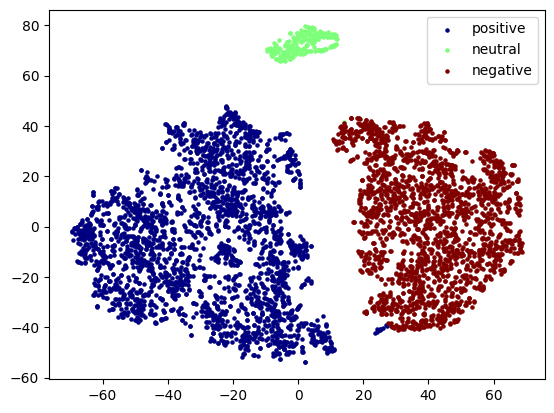

In [ ]:
#プロット
unique_labels = np.unique(pol_labels_np)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))

for i, num_label in enumerate(unique_labels):
    pol_label = inverse_pol_map[num_label]  # 数値ラベルをカテゴリ名に変換
    plt.scatter(pooler_output_2d[pol_labels_np == num_label, 0],
                pooler_output_2d[pol_labels_np == num_label, 1],
                color=colors[i],
                label=pol_label,
                s=5)

plt.legend()
plt.show()

## confusion matrix

In [ ]:
# モデルを評価モードに切り替える
model.eval()

# 予測と正解のリストを初期化
all_pol_preds = []
all_pol_labels = []

# DataLoaderからテストデータを1つずつ取り出して予測を行う
for target, sentence, pol_labels in test_dataloader:
    pol_labels = pol_labels.to(device)
    input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)

    with torch.no_grad():
        pred = model(**input)
        all_pol_preds.extend(torch.argmax(pred["pol_logits"], dim=1).cpu().numpy())
        all_pol_labels.extend(pol_labels.cpu().numpy())

In [ ]:
# Confusion Matrixの計算
pol_cm = confusion_matrix(all_pol_labels, all_pol_preds)

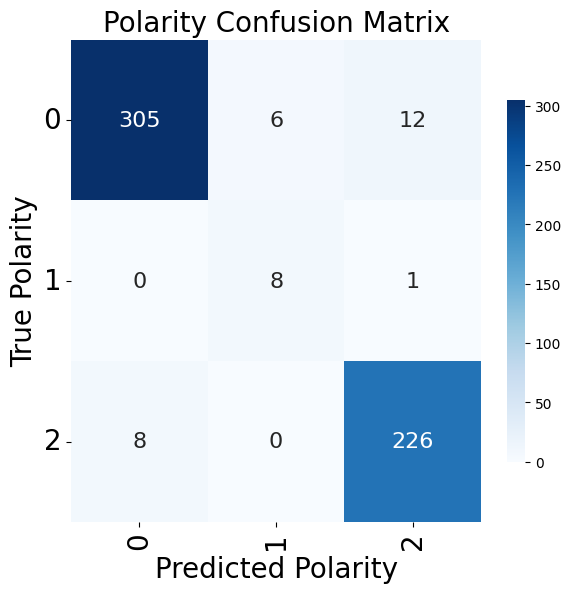

In [ ]:
# Confusion Matrixの計算後...
plt.figure(figsize=(6, 6))  # サイズ調整

sns.heatmap(pol_cm, annot=True, fmt="", cmap='Blues', cbar_kws={"shrink": 0.75}, annot_kws={"size": 16})
plt.xlabel('Predicted Polarity', fontsize=20)
plt.ylabel('True Polarity', fontsize=20)
plt.title('Polarity Confusion Matrix', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=90, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.show()

## Appendix

In [ ]:
#検証データでの検証

model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, total_samples = 0, 0, len(val_dataset)
pol_predictions, pol_labels_list = [], []

pooler_output = []

# 誤った予測とその詳細を記録するリスト
incorrect_polarity_samples = []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(val_dataloader):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })


avg_loss = total_loss / len(val_dataloader)
pol_accuracy = pol_total_correct / total_samples

# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')

# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

# 結果の出力
print(f"val Loss: {avg_loss:.4f}")
print(f"val Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

val Loss: 0.2275
val Pol Accuracy: 0.9620, F1: 0.8709
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       739
           1       0.80      0.60      0.69        20
           2       0.93      0.98      0.95       374

    accuracy                           0.96      1133
   macro avg       0.90      0.85      0.87      1133
weighted avg       0.96      0.96      0.96      1133

